# IMPORTANT NOTE: THIS NOTEBOOK SHOULD BE CONVERTED TO A "STANDARD" PYTHON SCRIPT ACCORDING TO THE NEW PROJECT STRUCTURE

# Data Analysis over CAN Bus using an Extended Kalman Filter
Now that we have seen how to properly deal with the data that we have available, it is time to define the proper structure of a script that loops over the whole dataset.

In [11]:
%load_ext autoreload
%autoreload 2

import os
import json
import numpy as np
import pandas as pd
from filterpy.common import Q_continuous_white_noise
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.signal import find_peaks
from filterpy.kalman import ExtendedKalmanFilter
from utilities import *
from motion_models import *

# Defining the constants for the analysis (i.e.: the can-line, and the message IDs)
ALFA_ROMEO_SPEED_IDs = ['0EE', '1F7']
OPEL_CORSA_SPEED_IDs = ['348']
OPEL_CORSA_RPM_IDs = ['0C9']
CAN_LINE = 'can0'
CAN_VAR_NAMES = ['HA_0', 'HA_1', 'HA_2']  # This list should be parsed dynamically, it is not a best practice to make it static

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The following code cell will deal with automatizing the fetch of the filenames over which the code will need to iterate over.

In [12]:
base_path = './data'
VEHICLES_FOLDERS = ['C-1-AlfaRomeo-Giulia', 'C-2-Opel-Corsa']
EXP_FOLDERS = [f'Exp-{i}' for i in range(1, 10)]
filename = 'unified.tar.gz'

# Parsing the file paths over which iterate
file_paths = []
for vehicle_name in VEHICLES_FOLDERS:
   for exp_folder in EXP_FOLDERS:
       path = f'{base_path}/{vehicle_name}/{exp_folder}/{filename}'
       if os.path.exists(path):
           file_paths.append(path)
print(file_paths)

['./data/C-1-AlfaRomeo-Giulia/Exp-1/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-2/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-3/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-4/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-5/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-6/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-7/unified.tar.gz', './data/C-1-AlfaRomeo-Giulia/Exp-8/unified.tar.gz', './data/C-2-Opel-Corsa/Exp-1/unified.tar.gz']


### Main Loop
The following code cell is the one that will effectively perform the loop over the files and the CAN readings in order to perform the actual prediction steps.
<br>For each experiment provided in ReCAN, there will be an output file in which we are going to store the data to retrieve it later.

In [18]:
# For each file we should loop over the whole dataset
for exp_file in file_paths:
    stats_dict = {'file': exp_file}
    print(f'!!!---- NOW PROCESSING {exp_file} ----!!!')
    # The first thing to do is converting the parsed file into a pandas dataframe leveraging the method in utilities
    # We will get the dataframe without binary readings since they are not very interesting in our context
    df = convert_to_dataframe(exp_file)
    stats_dict['total_file_records'] = len(df)
    print(f'The file {exp_file} has been converted to dataframe and has {len(df)} rows (non-binary records)')

    outfile_base_path = exp_file.replace('data', 'outputs').removesuffix('unified.tar.gz')

    # Setting the correct lists to be used while filtering the dataframe and defining the motion models
    if 'C-1' in exp_file:
        speed_ids = ALFA_ROMEO_SPEED_IDs
        rpm_ids = []
        motion_model = SpeedMotionModel(ALFA_ROMEO_SPEED_IDs)
        HJacobian = h_jacobian_speed
        Hx = observation_model_h
    else:
        speed_ids = OPEL_CORSA_SPEED_IDs
        rpm_ids = OPEL_CORSA_RPM_IDs
        motion_model = SpeedMotionModel(OPEL_CORSA_SPEED_IDs)
        HJacobian = h_jacobian_speed
        Hx = observation_model_h

    can_variables = get_var_names(df)
    print(f'-> CAN variables in current file: {can_variables}')

    # We must perform the prediction separately for every single variable
    for can_var_name in can_variables:
        print(f'======= CURRENTLY ANALYZING VARIABLE {can_var_name} for file {exp_file} =======')

        # --- INITIAL EKF SETUP (ONCE PER EACH FILE/EXPERIMENT) ---

        # Creating an instance of an EKF based on the initial data defined in the respective motion model
        ekf = ExtendedKalmanFilter(dim_x=motion_model.dim_x, dim_z=motion_model.dim_z)
        x_0, P_0 = motion_model.get_initial_state()
        ekf.x = x_0
        ekf.P = P_0

        # Loop over the data (filter by CAN_ID, CAN_line and datatype)
        # We are going to use the 80/20 method (80% of data used for Calibration of the filter, 20% of the data used for later testing)
        # As of now we are just keeping the first 80% of the values to enhance Calibration even more we may have to take the median 80% values
        # This should be revised later on to make the correct decision (like if it's ok to get the first 80% or we should get a random 80%)
        filtered_df = df[(df['id'].isin(speed_ids)) & (df['variable'] == can_var_name)]
        filtered_df.sort_values(by=['time'], inplace=True)
        data_records = filtered_df.to_dict('records')
        split_index = int(len(data_records) * 0.8)
        calibration_records = data_records[:split_index]
        print(f'Variable {can_var_name} -> Total frames: {len(filtered_df)}')
        print(f'Variable {can_var_name} -> Calibration frames (80%): {len(calibration_records)}')

        # --- LOOPING OVER THE FRAMES ---

        # For monitoring purposes define a list with the main values obtained from each iteration
        session_traces_list = []
        previous_signal = None
        cumulative_error = 0.0  # Track cumulative error to prevent potential attackers to inject slightly wrong data frames that would get accepted with threshold only check
        iteration_id = 0  # identifier used for tracking reasons
        outfile_path = f'{outfile_base_path}test_session_trace_{can_var_name}.json'
        for signal in data_records:
            session_trace = {'iteration_id': iteration_id}

            # --- READING THE ACTUAL NEXT VALUE (and converting it in m/s) ---
            signal_value = float(signal['value'])
            if signal['id'] in speed_ids:
                signal_value = (signal_value * 0.05) / 3.6
            z_k = np.array([[signal_value]])
            session_trace['timestamp'] = str(signal['time'])
            session_trace['signal_value'] = signal_value

            # If it's the first signal, we must assume delta_time as 0
            if previous_signal is None:
                delta_time = 0
            else:
                delta_time = (signal['time'] - previous_signal['time']).total_seconds()
            # Guard against out-of-order serial logging artifacts (time will not go backwards, thus delta_time can never be negative)
            if delta_time < 0:
                continue
            session_trace['delta_time'] = delta_time

            # --- USING THE EKF TO PERFORM THE PREDICTION (PREDICT THE CURRENT VALUE BASED ON THE PREVIOUS STATE) ---
            # We can now extract the other matrices from the motion model to update the EKF
            x_new, F, Q, R = motion_model.get_transition_stage_data(ekf.x, delta_time)
            ekf.x = x_new
            ekf.F = F
            ekf.Q = Q
            ekf.R = R
            # Updating the Covariance Matrix P through the "standard" procedure
            ekf.P = np.dot(ekf.F, ekf.P).dot(ekf.F.T) + ekf.Q

            # Performing the correction/update step for the EKF
            ekf.update(z=z_k, HJacobian=HJacobian, Hx=Hx)
            session_trace['predicted_next_value'] = ekf.x[0, 0]

            # --- PREDICTION EVALUATION AND ITERATION LOGGING ---
            # Note: we can use the residual, however we should refine our approach for a bit because we would need to consider
            # the EKF prediction as the Ground Truth, and we should then compare the received data to see whether it falls within the right distribution
            y_k = float(ekf.y[0, 0])  # Innovation Residual - Represents the prediction error
            cumulative_error += y_k  # Updating the cumulative error with the residual for the current signal
            variance_s = float(ekf.S[0, 0])  # Innovation Covariance Matrix S, which we will use to define a threshold
            evaluation_threshold = 3.0 * np.sqrt(variance_s)  # The threshold to identify errors over a single iteration
            session_trace['residual_error'] = ekf.y[0, 0]
            session_trace['evaluation_threshold'] = evaluation_threshold
            session_trace['cumulative_error'] = cumulative_error

            # --- PREPARING FOR NEXT ITERATION ---
            # Once all the evaluations are correctly done, save the current signal into the "previous_signal" variable in order to compute delta_time properly
            previous_signal = signal
            iteration_id += 1
            session_traces_list.append(session_trace)
        # Storing the traces in an external file to ease an evaluation performed later on
        print(f'Terminated {can_var_name} analysis, now storing results in {outfile_path}...')
        # No need to print a trace if no record has been evaluated
        if iteration_id != 0:
            with open(outfile_path, 'w') as outfile:
                json.dump(session_traces_list, outfile)
            # To define the boundaries let's find the maximum values (we are going to need this during the "test" stage)
            metrics_df = pd.DataFrame(session_traces_list)
            max_abs_residual = metrics_df['residual_error'].abs().max()
            max_abs_cumulative = metrics_df['cumulative_error'].abs().max()
            print(f'** {can_var_name} BASELINE METRICS **')
            print(f'Var {can_var_name} Maximum Absolute Residual (Single-Frame): {max_abs_residual:.6f} m/s')
            print(f'Var {can_var_name} Maximum Absolute Cumulative Drift:        {max_abs_cumulative:.6f} m/s')

!!!---- NOW PROCESSING ./data/C-1-AlfaRomeo-Giulia/Exp-1/unified.tar.gz ----!!!
The file ./data/C-1-AlfaRomeo-Giulia/Exp-1/unified.tar.gz has been converted to dataframe and has 6537316 rows (non-binary records)
-> CAN variables in current file: ['HA_0', 'HA_1', 'HA_2', 'NI_0', 'NI_1', 'BY_0', 'BY_1', 'WO_0', 'NI_2', 'NI_3', 'NI_4', 'NI_5', 'NI_6', 'NI_7', 'NI_8', 'NI_9', 'NI_10']
======= CURRENTLY ANALYZING VARIABLE HA_0 for file ./data/C-1-AlfaRomeo-Giulia/Exp-1/unified.tar.gz =======
Variable HA_0 -> Total frames: 173977
Variable HA_0 -> Calibration frames (80%): 139181
Terminated HA_0 analysis, now storing results in ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/test_session_trace_HA_0.json...
** HA_0 BASELINE METRICS **
Var HA_0 Maximum Absolute Residual (Single-Frame): 6.030743 m/s
Var HA_0 Maximum Absolute Cumulative Drift:        375.017607 m/s
======= CURRENTLY ANALYZING VARIABLE HA_1 for file ./data/C-1-AlfaRomeo-Giulia/Exp-1/unified.tar.gz =======
Variable HA_1 -> Total frames: 11590

### Charting the traces
In the previous cell we performed the computational step, where we iterated over the data and used the EKF to perform predictions and saved the results in a JSON file.
<br>In this cell we are now going to reorganize the output data into a Gaussian distribution to achieve a better analysis of the results.


=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/test_session_trace_HA_0.json ===========

2 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


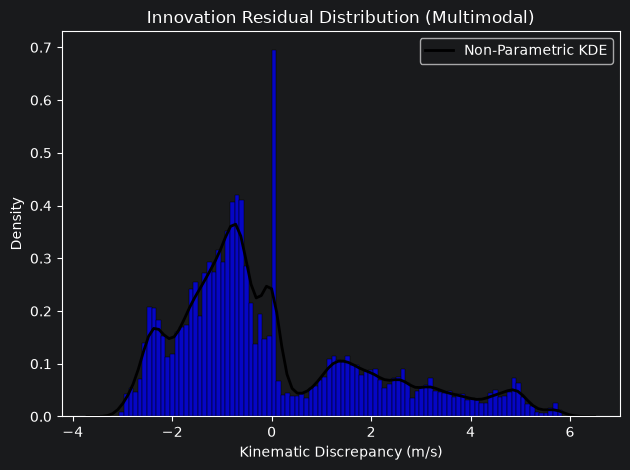

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.002045 m/s
Standard Dev (sigma): 1.960404 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/test_session_trace_HA_1.json ===========
Shapiro-Wilk Test -> Statistic: 0.9567, p-value: 3.4962e-36
 - Norm     KS-Statistic: 0.0804 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0289 (p-value: 1.1306e-84)
 - Chi2     KS-Statistic: 0.5145 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.4955 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.3477 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


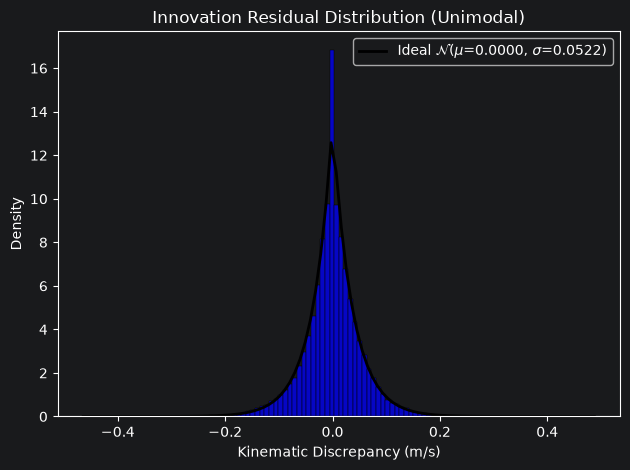

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.052219 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.9399, p-value: 5.0682e-41
 - Norm     KS-Statistic: 0.0928 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0391 (p-value: 3.9490e-154)
 - Chi2     KS-Statistic: 0.1631 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5383 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.3924 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


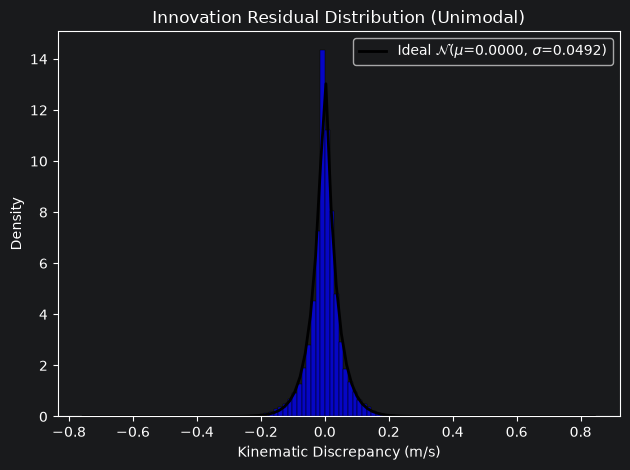

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.049178 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-2/test_session_trace_HA_0.json ===========

2 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


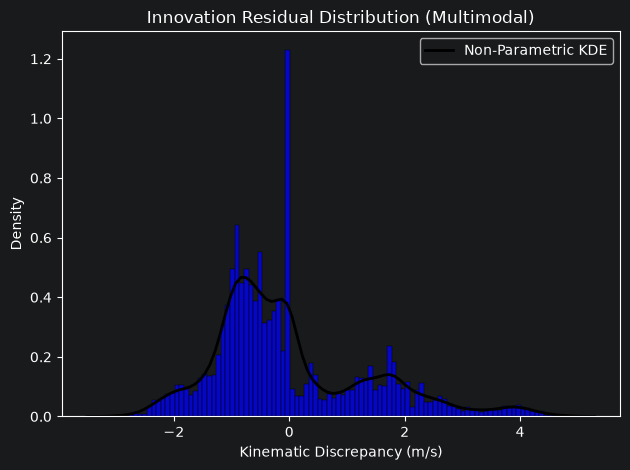

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.000986 m/s
Standard Dev (sigma): 1.364775 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-2/test_session_trace_HA_1.json ===========
Shapiro-Wilk Test -> Statistic: 0.7252, p-value: 9.6134e-68
 - Norm     KS-Statistic: 0.1522 (p-value: 6.7943e-280)
 - Laplace  KS-Statistic: 0.0594 (p-value: 8.2016e-43)
 - Chi2     KS-Statistic: 0.1537 (p-value: 1.5719e-285)
 - Pareto   KS-Statistic: 0.5536 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.5097 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


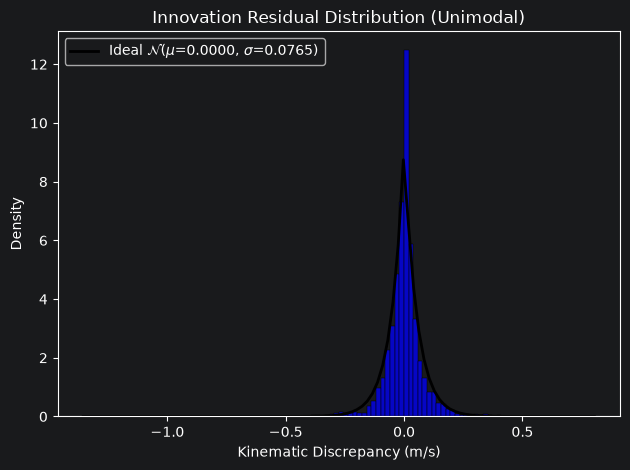

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.076539 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-2/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.7263, p-value: 1.1657e-67
 - Norm     KS-Statistic: 0.1623 (p-value: 1.9424e-318)
 - Laplace  KS-Statistic: 0.0656 (p-value: 4.2552e-52)
 - Chi2     KS-Statistic: 0.1487 (p-value: 5.6143e-267)
 - Pareto   KS-Statistic: 0.5398 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.4440 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


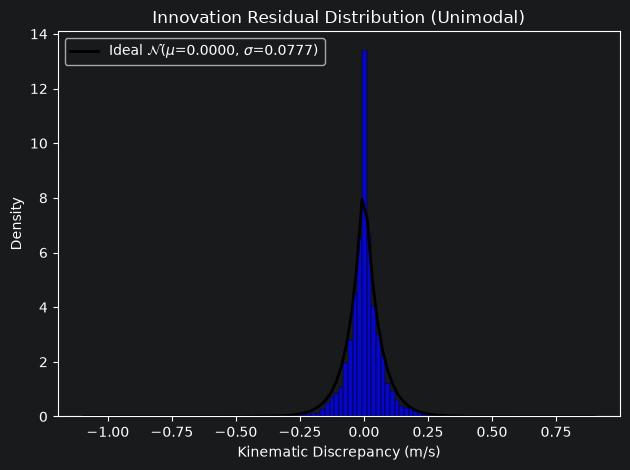

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.077683 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-4/test_session_trace_HA_0.json ===========

3 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


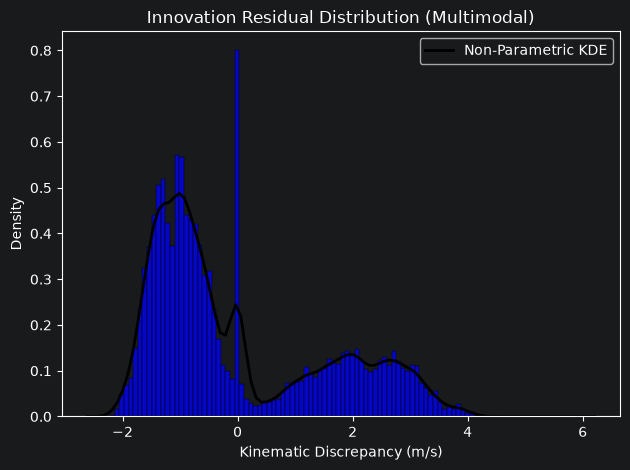

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.001830 m/s
Standard Dev (sigma): 1.542055 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-4/test_session_trace_HA_1.json ===========
Shapiro-Wilk Test -> Statistic: 0.9549, p-value: 9.4932e-37
 - Norm     KS-Statistic: 0.0891 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0266 (p-value: 1.1231e-75)
 - Chi2     KS-Statistic: 0.2458 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5557 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.5004 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


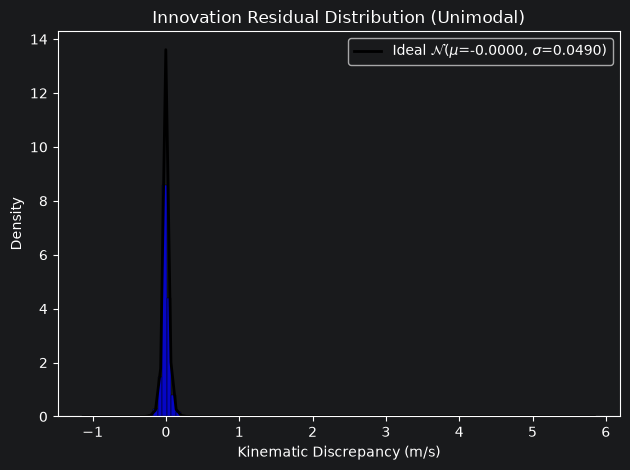

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): -0.000000 m/s
Standard Dev (sigma): 0.049025 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-4/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.9146, p-value: 1.3391e-46
 - Norm     KS-Statistic: 0.1021 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0281 (p-value: 1.6670e-84)
 - Chi2     KS-Statistic: 0.5370 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5410 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.3882 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


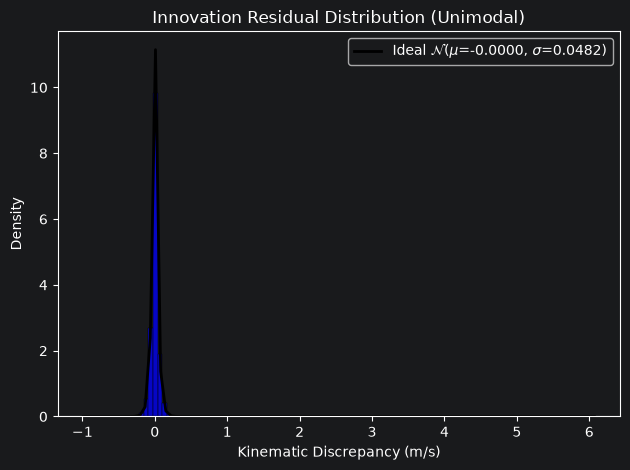

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): -0.000000 m/s
Standard Dev (sigma): 0.048151 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-5/test_session_trace_HA_0.json ===========

2 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


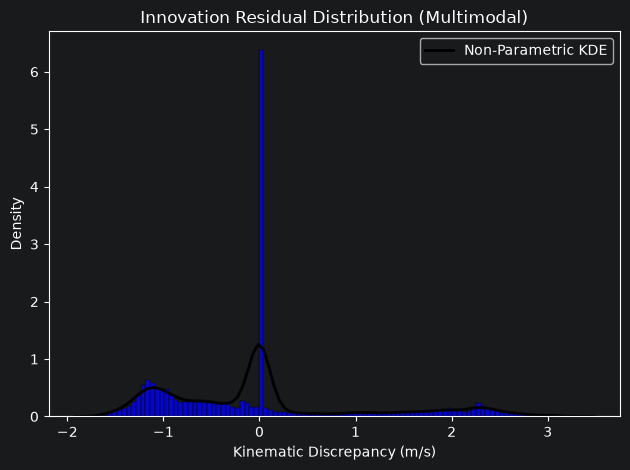

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.000930 m/s
Standard Dev (sigma): 1.069532 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-5/test_session_trace_HA_1.json ===========

3 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


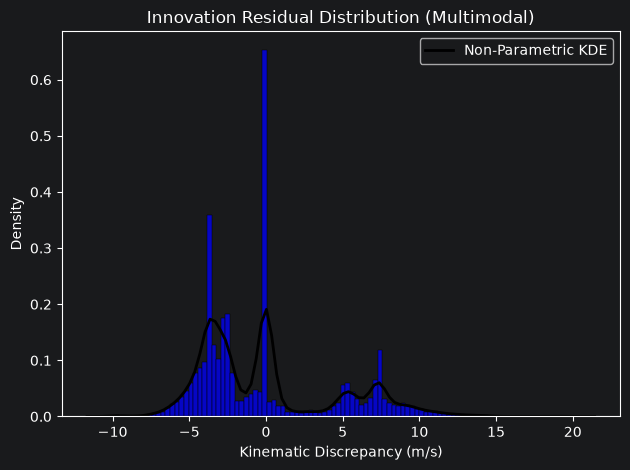

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.004587 m/s
Standard Dev (sigma): 4.547233 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-5/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.8522, p-value: 5.1411e-56
 - Norm     KS-Statistic: 0.1549 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.1481 (p-value: 0.0000e+00)
 - Chi2     KS-Statistic: 0.3245 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5237 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.4362 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


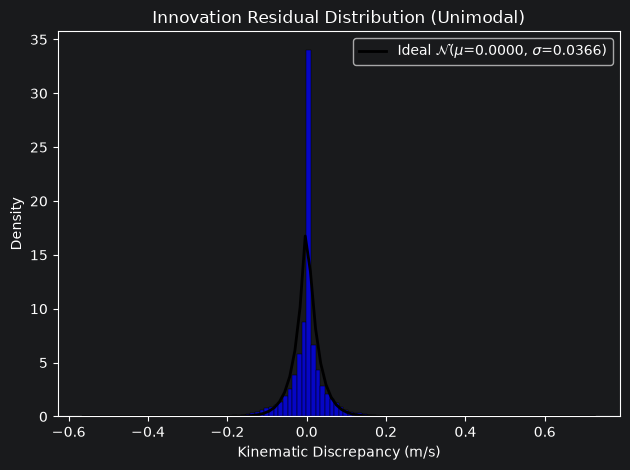

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.036626 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-6/test_session_trace_HA_0.json ===========

3 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


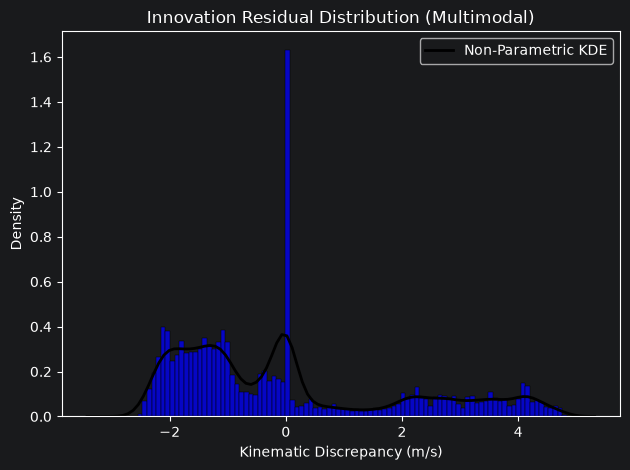

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.002070 m/s
Standard Dev (sigma): 1.953063 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-6/test_session_trace_HA_1.json ===========

3 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


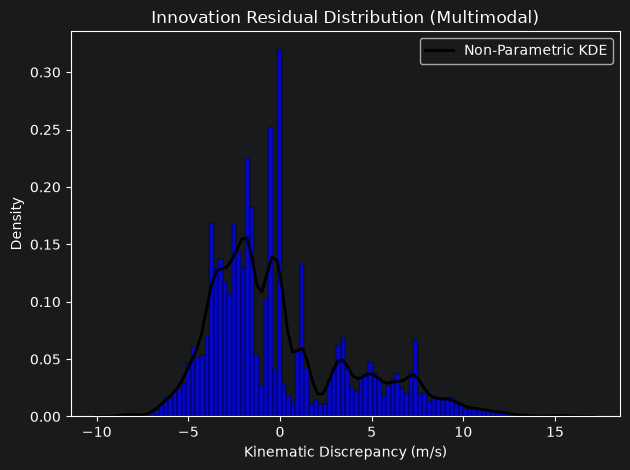

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.004195 m/s
Standard Dev (sigma): 3.954098 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-6/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.8963, p-value: 8.1214e-50
 - Norm     KS-Statistic: 0.1059 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0631 (p-value: 2.1425e-221)
 - Chi2     KS-Statistic: 0.2160 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5487 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.5626 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


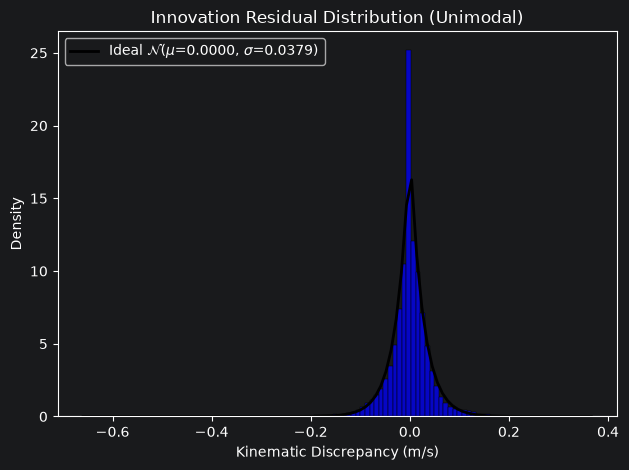

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.037879 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-7/test_session_trace_HA_0.json ===========

3 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


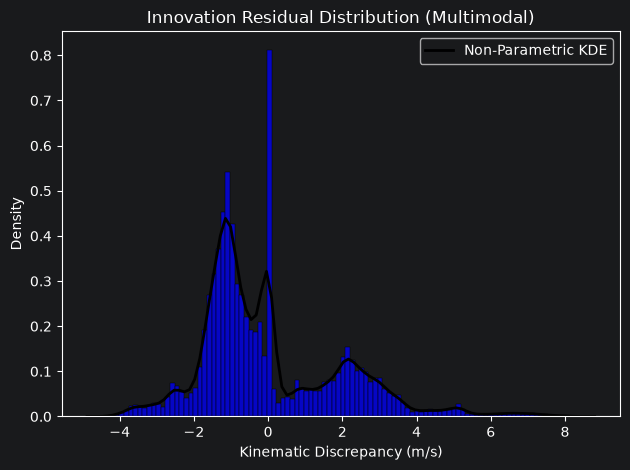

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.001504 m/s
Standard Dev (sigma): 1.898512 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-7/test_session_trace_HA_1.json ===========
Shapiro-Wilk Test -> Statistic: 0.9203, p-value: 1.7920e-45
 - Norm     KS-Statistic: 0.1057 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0475 (p-value: 9.7876e-203)
 - Chi2     KS-Statistic: 0.2997 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5385 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.4170 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


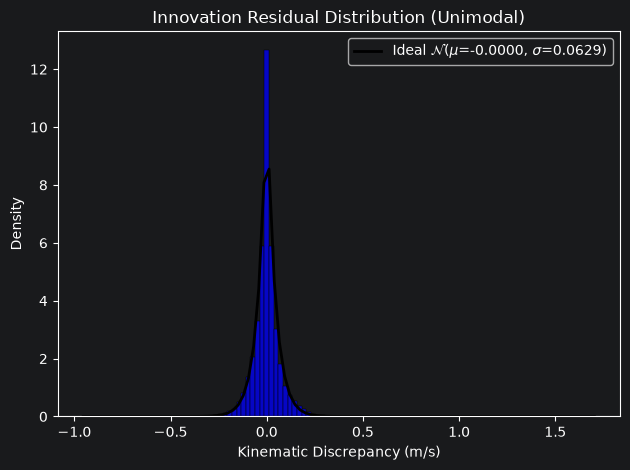

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): -0.000000 m/s
Standard Dev (sigma): 0.062907 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-7/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.8902, p-value: 8.6142e-51
 - Norm     KS-Statistic: 0.1275 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.0514 (p-value: 2.1048e-237)
 - Chi2     KS-Statistic: 0.1319 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5707 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.4801 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


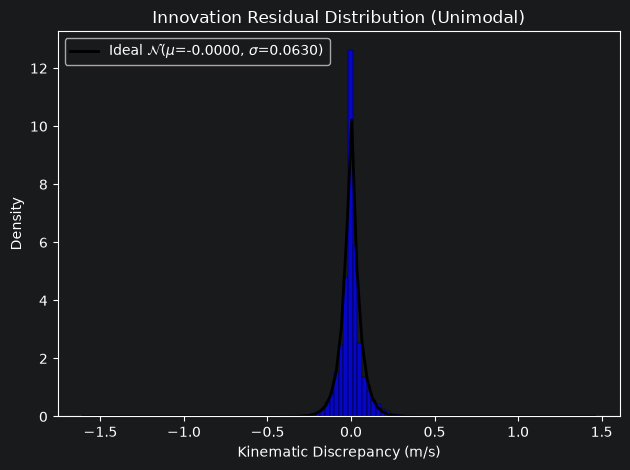

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): -0.000000 m/s
Standard Dev (sigma): 0.062999 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-8/test_session_trace_HA_0.json ===========

2 PEAKS DETECTED: Distribution is Bimodal/Multimodal. Falling back to KDE.


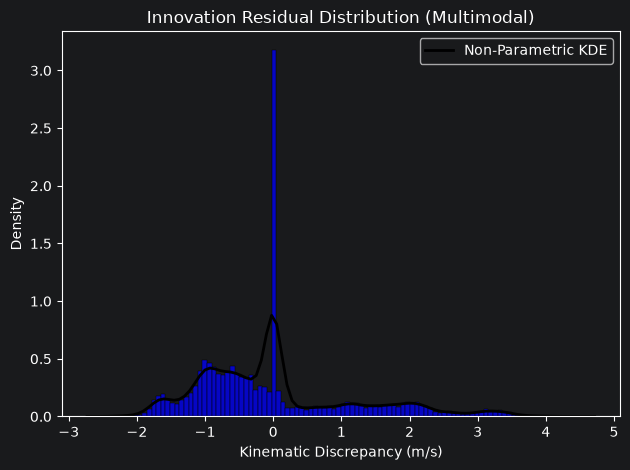

** Multimodal DISTRIBUTION METRICS **
Mean Error (mu): -0.001177 m/s
Standard Dev (sigma): 1.160643 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-8/test_session_trace_HA_1.json ===========
Shapiro-Wilk Test -> Statistic: 0.9092, p-value: 1.3577e-47
 - Norm     KS-Statistic: 0.1268 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.1050 (p-value: 0.0000e+00)
 - Chi2     KS-Statistic: 0.3435 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.4626 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.4241 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


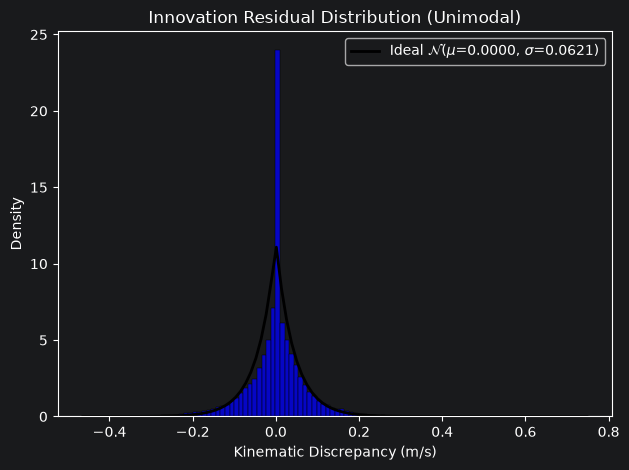

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.062120 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-1-AlfaRomeo-Giulia/Exp-8/test_session_trace_HA_2.json ===========
Shapiro-Wilk Test -> Statistic: 0.9145, p-value: 1.3305e-46
 - Norm     KS-Statistic: 0.1297 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.1028 (p-value: 0.0000e+00)
 - Chi2     KS-Statistic: 0.1499 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5005 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.3879 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


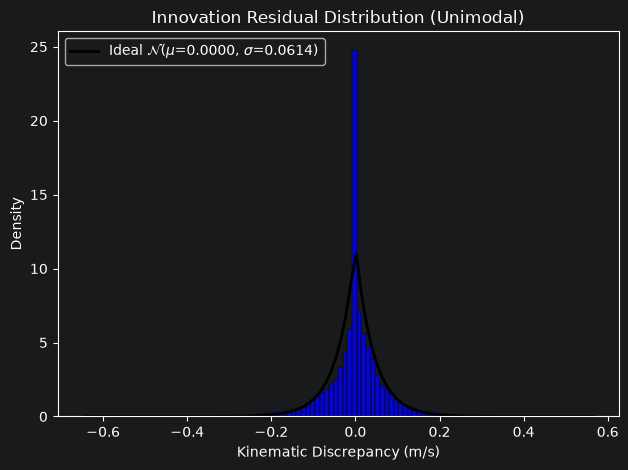

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.061350 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-2-Opel-Corsa/Exp-1/test_session_trace_HA_0.json ===========
Shapiro-Wilk Test -> Statistic: 0.8937, p-value: 2.9923e-50
 - Norm     KS-Statistic: 0.1372 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.1168 (p-value: 0.0000e+00)
 - Chi2     KS-Statistic: 0.1556 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5033 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.3619 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


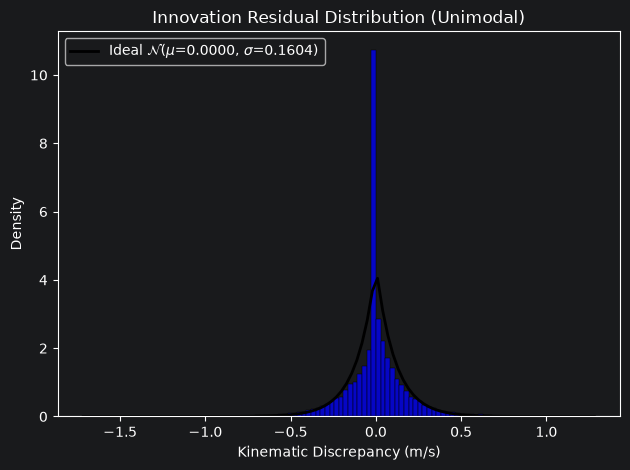

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.160389 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-2-Opel-Corsa/Exp-1/test_session_trace_HA_1.json ===========
Shapiro-Wilk Test -> Statistic: 0.8807, p-value: 3.1627e-52
 - Norm     KS-Statistic: 0.1405 (p-value: 0.0000e+00)
 - Laplace  KS-Statistic: 0.1166 (p-value: 0.0000e+00)
 - Chi2     KS-Statistic: 0.1562 (p-value: 0.0000e+00)
 - Pareto   KS-Statistic: 0.5076 (p-value: 0.0000e+00)
 - Truncnorm KS-Statistic: 0.4106 (p-value: 0.0000e+00)

The most suitable statistical distribution is: Laplace


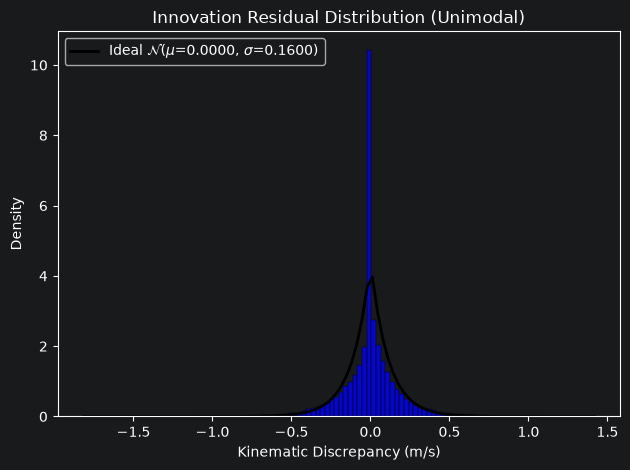

** Laplace DISTRIBUTION METRICS **
Mean Error (mu): 0.000000 m/s
Standard Dev (sigma): 0.159986 m/s

=========== NOW CHARTING TRACE FILE ./outputs/C-2-Opel-Corsa/Exp-1/test_session_trace_HA_2.json ===========


In [19]:
# Load the output data into a dataframe
traces_files = []
for vehicle_name in VEHICLES_FOLDERS:
   for exp_folder in EXP_FOLDERS:
       for var_name in CAN_VAR_NAMES:
           path = f'./outputs/{vehicle_name}/{exp_folder}/test_session_trace_{var_name}.json'
           if os.path.exists(path):
               traces_files.append(path)

# The metrics that we are going to plot should also be stored in a separate file that can be used in the later stages of
# the project where we will be taking values not used to Calibrate the EKF and we need to test if they fall in the acceptable range
# To do so we are going to leverage a dedicated method defined in utilities.py to parse the names to create a file

for f in traces_files:
    print(f'\n=========== NOW CHARTING TRACE FILE {f} ===========')
    tracing_dict = json.load(open(f, 'r'))
    tracing_df = pd.DataFrame(tracing_dict)

    # Eventually loading the metrics dictionary, creating it otherwise
    vehicle_name, experiment_id, var_name = get_info_from_path(f)
    metrics_filepath = f'./outputs/{vehicle_name}/{experiment_id}/metrics.json'
    if os.path.exists(metrics_filepath):
        metrics_dict = json.load(open(metrics_filepath, 'r'))
        metrics_dict[var_name] = {}
    else:
        metrics_dict = {}
    # By loading/creating the metrics dictionary the way we just did we are able to overwrite the metrics file without worrying

    if len(tracing_df) > 0:
        steady_state_errors = tracing_df['residual_error']

        # Check which statistical distribution suits best our data
        best_params, best_dist_name = check_statistical_distribution(tracing_df)

        fig, axes = plt.subplots()

        sns.histplot(steady_state_errors, bins=100, kde=False, ax=axes, color='blue', stat='density')
        xmin, xmax = axes.get_xlim()
        x = np.linspace(xmin, xmax, 100)

        # If the distribution is Bimodal/Multimodal we should handle the respective object accordingly
        if best_dist_name == 'kde':
            kde_obj = best_params
            p = kde_obj(x)
            # Since KDE doesn't have a theoretical mean/std, calculate from the raw data
            mu = steady_state_errors.mean()
            std = steady_state_errors.std()
            axes.plot(x, p, 'k', linewidth=2, label=f'Non-Parametric KDE')
            axes.set_title('Innovation Residual Distribution (Multimodal)')
        else:
            # Leveraging the custom statistical check that has been defined in the utilities.py file
            best_dist_obj = getattr(stats, best_dist_name)
            p = best_dist_obj.pdf(x, *best_params)
            mu = best_dist_obj.mean(*best_params)
            std = best_dist_obj.std(*best_params)
            axes.plot(x, p, 'k', linewidth=2, label=f'Ideal $\\mathcal{{N}}$($\\mu$={mu:.4f}, $\\sigma$={std:.4f})')
            axes.set_title('Innovation Residual Distribution (Unimodal)')

        # Common parameters and plotting the chart
        axes.set_xlabel('Kinematic Discrepancy (m/s)')
        axes.set_ylabel('Density')
        axes.legend()
        plt.tight_layout()
        plt.show()

        if best_dist_name == 'kde':
            metrics_title = 'Multimodal'
        else:
            metrics_title = best_dist_name.capitalize()
        print(f'** {metrics_title} DISTRIBUTION METRICS **')
        print(f'Mean Error (mu): {mu:.6f} m/s')
        print(f'Standard Dev (sigma): {std:.6f} m/s')

        # Updating the metrics dictionary and storing it into the respective file
        metrics_dict[var_name] = {
            'distribution': metrics_title,
            'mean': mu,
            'std_deviation': std,
            'max_cumulative_error': tracing_df['cumulative_error'].max()
        }
        with open(metrics_filepath, 'w') as metrics_file:
            json.dump(metrics_dict, metrics_file)

### Testing the filter over "external" data
The next step is to test the EKF implementation/model we just defined over the data that we didn't use to calibrate the filters.
The statistical/mathematical results obtained are now stored in a separate file, we should then test with the other 20% of data we didn't use to calibrate the filter in order to test how good it is.
<br>This is exactly what we are going to do in the next code cell of the notebook

In [20]:
# Fetching the metrics files
metrics_files = []
for vehicle_name in VEHICLES_FOLDERS:
   for exp_folder in EXP_FOLDERS:
       path = f'./outputs/{vehicle_name}/{exp_folder}/metrics.json'
       if os.path.exists(path):
           metrics_files.append(path)

# Looping over the data
for exp_file in file_paths:
    print(f'========== NOW TESTING VALIDATION SET FOR {exp_file} ==========')
    df = convert_to_dataframe(exp_file)

    # Loading the metrics dictionary
    vehicle_name, experiment_id, dummy_var = get_info_from_path(exp_file)
    metrics_filepath = f'./outputs/{vehicle_name}/{experiment_id}/metrics.json'
    try:
        with open(metrics_filepath, 'r') as f:
            metrics_dict = json.load(f)
    except FileNotFoundError:
        print(f'ERROR: Metrics file not found for {exp_file}. Run Calibration stage first!')
        continue

    # Set up the data using the same logic (in terms of motion model, functions and parameters)
    # TODO: Make this step a function or adopt a different strategy to avoid code replication
    if 'C-1' in exp_file:
        speed_ids = ALFA_ROMEO_SPEED_IDs
        motion_model = SpeedMotionModel(ALFA_ROMEO_SPEED_IDs)
    else:
        speed_ids = OPEL_CORSA_SPEED_IDs
        motion_model = SpeedMotionModel(OPEL_CORSA_SPEED_IDs)
    HJacobian = h_jacobian_speed
    Hx = observation_model_h
    can_variables = get_var_names(df)

    outfile_base_path = exp_file.replace('data', 'outputs').removesuffix('unified.tar.gz')

    # ----- LOOPING OVER THE VARIABLES -----
    for can_var_name in can_variables:
        if can_var_name not in metrics_dict:
            continue
        print(f'======= Testing Variable {can_var_name} =======')
        outfile_path = f'{outfile_base_path}validation_trace_{can_var_name}.json'
        # Loading the calibrated parameters that have been read from the file
        calibrated_mu = metrics_dict[can_var_name]['mean']
        calibrated_sigma = metrics_dict[can_var_name]['std_deviation']
        # We add a 10% safety buffer to the maximum cumulative drift to avoid false positives (which may be triggered by the cold-start in an actual warm-start scenario)
        max_allowed_drift = metrics_dict[can_var_name]['max_cumulative_error'] * 1.10

        # Fetching the "remaining 20%" of the data over which we are going to test
        filtered_df = df[(df['id'].isin(speed_ids)) & (df['variable'] == can_var_name)]
        filtered_df.sort_values(by=['time'], inplace=True)
        data_records = filtered_df.to_dict('records')
        split_index = int(len(data_records) * 0.8)
        validation_records = data_records[split_index:]


        ekf = ExtendedKalmanFilter(dim_x=motion_model.dim_x, dim_z=motion_model.dim_z)
        ekf.x, ekf.P = motion_model.get_initial_state()

        session_traces_list = []
        previous_signal = None
        cumulative_error = 0.0
        iteration_id = 0
        for signal in validation_records:
            signal_value = float(signal['value'])
            if signal['id'] in speed_ids:
                # Scaling factor for the value
                signal_value = (signal_value * 0.05) / 3.6
            z_k = np.array([[signal_value]])

            if previous_signal is None:
                delta_time = 0
            else:
                delta_time = (signal['time'] - previous_signal['time']).total_seconds()
            # Guard against out-of-order values
            if delta_time < 0:
                continue

            # EKF innovation/update cycle
            x_new, F, Q, R = motion_model.get_transition_stage_data(ekf.x, delta_time)
            ekf.x = x_new
            ekf.F = F
            ekf.Q = Q
            ekf.R = R
            ekf.P = np.dot(ekf.F, ekf.P).dot(ekf.F.T) + ekf.Q

            ekf.update(z=z_k, HJacobian=HJacobian, Hx=Hx)

            # Residual value
            y_k = float(ekf.y[0, 0])
            cumulative_error += y_k
            variance_s = float(ekf.S[0, 0])
            evaluation_threshold = 3.0 * np.sqrt(variance_s)

            # Coherency check -> we are going to check if the current value falls within an admissible range
            is_anomaly = False
            anomaly_type = "None"
            if abs(y_k - calibrated_mu) > (3.0 * calibrated_sigma):
                is_anomaly = True
                anomaly_type = "signalOutOfRange"
            elif abs(cumulative_error) > max_allowed_drift:
                is_anomaly = True
                anomaly_type = "cumulativeError"

            # Save the results
            session_traces_list.append({
                'iteration_id': iteration_id,
                'timestamp': str(signal['time']),
                'measured_value': signal_value,
                'predicted_value': ekf.x[0, 0],
                'residual_error': y_k,
                'cumulative_error': cumulative_error,
                'is_anomaly': is_anomaly,
                'anomaly_type': anomaly_type
            })

            # Updating the values, going through with the next signal
            previous_signal = signal
            iteration_id += 1
        # Storing the traces in an external file to ease an evaluation performed later on
        print(f'Terminated {can_var_name} validation, now storing results in {outfile_path}...')
        # Quick Print Summary
        if iteration_id > 0:
            test_df = pd.DataFrame(session_traces_list)
            total_anomalies = test_df['is_anomaly'].sum()
            print(f' -> Validated {len(test_df)} frames. Found {total_anomalies} anomalies.')
            with open(outfile_path, 'w') as outfile:
                json.dump(session_traces_list, outfile)
            # To define the boundaries let's find the maximum values (we are going to need this during the "test" stage)
            metrics_df = pd.DataFrame(session_traces_list)
            max_abs_residual = metrics_df['residual_error'].abs().max()
            max_abs_cumulative = metrics_df['cumulative_error'].abs().max()
            print(f'** {can_var_name} BASELINE METRICS **')
            print(f'Var {can_var_name} Maximum Absolute Residual (Single-Frame): {max_abs_residual:.6f} m/s')
            print(f'Var {can_var_name} Maximum Absolute Cumulative Drift:        {max_abs_cumulative:.6f} m/s')

========== NOW TESTING VALIDATION SET FOR ./data/C-1-AlfaRomeo-Giulia/Exp-1/unified.tar.gz ==========
======= Testing Variable HA_0 =======
Terminated HA_0 validation, now storing results in ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/validation_trace_HA_0.json...
 -> Validated 34796 frames. Found 14449 anomalies.
** HA_0 BASELINE METRICS **
Var HA_0 Maximum Absolute Residual (Single-Frame): 9.916667 m/s
Var HA_0 Maximum Absolute Cumulative Drift:        66.657493 m/s
======= Testing Variable HA_1 =======
Terminated HA_1 validation, now storing results in ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/validation_trace_HA_1.json...
 -> Validated 23181 frames. Found 824 anomalies.
** HA_1 BASELINE METRICS **
Var HA_1 Maximum Absolute Residual (Single-Frame): 9.958333 m/s
Var HA_1 Maximum Absolute Cumulative Drift:        33.393876 m/s
======= Testing Variable HA_2 =======
Terminated HA_2 validation, now storing results in ./outputs/C-1-AlfaRomeo-Giulia/Exp-1/validation_trace_HA_2.json...
 -> Validated 23